In [1]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from pytorch_msssim import SSIM
import cv2

In [2]:
import sys
!{sys.executable} -m pip install opencv-python


Defaulting to user installation because normal site-packages is not writeable


In [2]:
f_train_high = os.path.expanduser("~/Desktop/VS code projects/LOLv1/train/high")
train_high = [f for f in os.listdir(f_train_high) if f.endswith(('.jpg', '.jpeg', '.png', '.gif'))]

f_train_low = os.path.expanduser("~/Desktop/VS code projects/LOLv1/train/low")
train_low = [f for f in os.listdir(f_train_low) if f.endswith(('.jpg', '.jpeg', '.png', '.gif'))]




f_test_high = os.path.expanduser("~/Desktop/VS code projects/LOLv1/test/high")
test_high = [f for f in os.listdir(f_test_high) if f.endswith(('.jpg', '.jpeg', '.png', '.gif'))]

f_test_low = os.path.expanduser("~/Desktop/VS code projects/LOLv1/test/low")
test_low = [f for f in os.listdir(f_test_low) if f.endswith(('.jpg', '.jpeg', '.png', '.gif'))]


In [25]:
def load_images(folder, filenames, size=(128, 128)):
    folder = os.path.expanduser(folder)
    images = []
    for f in filenames:
        img = Image.open(os.path.join(folder, f)).convert("RGB")
        img = img.resize(size)                        # resize to consistent shape
        img = np.array(img) / 255.0                   # normalize to [0, 1]
        images.append(img)
    return np.array(images)

In [4]:
def darken_gamma(imgs, gamma=1.5):
    """Apply gamma darkening to a numpy array of images"""
    return (imgs ** gamma).clip(0, 1)

def night_vision(imgs):
    """
    Convert to night vision green tint
    imgs: numpy array (N, H, W, 3)
    """
    filtered = imgs.copy()
    
    # Convert to greyscale first
    grey = 0.299 * filtered[:,:,:,0] + 0.587 * filtered[:,:,:,1] + 0.114 * filtered[:,:,:,2]
    
    # Map greyscale to green channel only
    result = np.zeros_like(filtered)
    result[:,:,:,0] = grey * 0.1   # very little red
    result[:,:,:,1] = grey * 1.0   # full green
    result[:,:,:,2] = grey * 0.1   # very little blue
    
    return result.clip(0, 1)


In [ ]:
set_size=(128,128)
train_high_imgs = load_images("~/Desktop/VS code projects/LOLv1/train/high", train_high,size=set_size)
train_low_imgs  = load_images("~/Desktop/VS code projects/LOLv1/train/low",  train_low,size=set_size)
test_high_imgs  = load_images("~/Desktop/VS code projects/LOLv1/test/high",  test_high,size=set_size)
test_low_imgs   = load_images("~/Desktop/VS code projects/LOLv1/test/low",   test_low,size=set_size)

train_low_imgs = darken_gamma(train_low_imgs, gamma=2.5)
test_low_imgs  = darken_gamma(test_low_imgs,  gamma=2.5)

# Apply to high light target images
train_high_imgs = night_vision(train_high_imgs)
test_high_imgs  = night_vision(test_high_imgs)

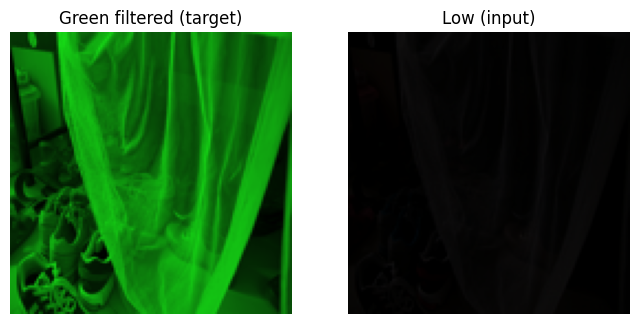

In [27]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(train_high_imgs[0])
axes[0].set_title("Green filtered (target)")
axes[1].imshow(train_low_imgs[0])
axes[1].set_title("Low (input)")
for ax in axes: ax.axis('off')
plt.show()

In [28]:


class LOLDataset(Dataset):
    def __init__(self, low_imgs, high_imgs):
        # Convert numpy arrays to tensors, move channels first (N,H,W,C) -> (N,C,H,W)
        self.low  = torch.tensor(low_imgs,  dtype=torch.float32).permute(0, 3, 1, 2)
        self.high = torch.tensor(high_imgs, dtype=torch.float32).permute(0, 3, 1, 2)

    def __len__(self):
        return len(self.low)

    def __getitem__(self, idx):
        return self.low[idx], self.high[idx]

# Create dataloaders
train_dataset = LOLDataset(train_low_imgs, train_high_imgs)
test_dataset  = LOLDataset(test_low_imgs,  test_high_imgs)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False)

In [29]:
def to_night_vision(output_tensor):
    grey = output_tensor.squeeze(0).permute(1, 2, 0).cpu().numpy()
    grey = 0.299 * grey[:,:,0] + 0.587 * grey[:,:,1] + 0.114 * grey[:,:,2]
    
    # Stretch contrast so dark is darker and bright is brighter
    grey = (grey - grey.min()) / (grey.max() - grey.min() + 1e-6)
    
    # Increase contrast with gamma
    grey = grey ** 0.6  # < 1 brightens midtones, try 0.4 - 0.8
    
    result = np.zeros((grey.shape[0], grey.shape[1], 3))
    result[:,:,0] = grey * 0.1
    result[:,:,1] = grey * 0.9
    result[:,:,2] = grey * 0.1
    return result.clip(0, 1)

In [12]:
from pytorch_msssim import SSIM

In [30]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder
        self.enc1 = DoubleConv(3, 32)
        self.enc2 = DoubleConv(32, 64)
        self.enc3 = DoubleConv(64, 128)
        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(128, 256)

        # Decoder
        self.up1 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec1 = DoubleConv(256, 128)  # 256 because of skip connection
        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = DoubleConv(128, 64)
        self.up3 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec3 = DoubleConv(64, 32)

        # Output
        self.out = nn.Conv2d(32, 3, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Encoder
        c1 = self.enc1(x)
        c2 = self.enc2(self.pool(c1))
        c3 = self.enc3(self.pool(c2))

        # Bottleneck
        b = self.bottleneck(self.pool(c3))

        # Decoder + skip connections
        u1 = self.up1(b)
        u1 = torch.cat([u1, c3], dim=1)
        u1 = self.dec1(u1)

        u2 = self.up2(u1)
        u2 = torch.cat([u2, c2], dim=1)
        u2 = self.dec2(u2)

        u3 = self.up3(u2)
        u3 = torch.cat([u3, c1], dim=1)
        u3 = self.dec3(u3)

        return self.sigmoid(self.out(u3))

In [32]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

model = UNet().to(device)

class DetailLoss(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.mse  = torch.nn.MSELoss()
        self.ssim = SSIM(data_range=1.0, size_average=True, channel=3)

    def forward(self, pred, target):
        mse_loss  = self.mse(pred, target)
        ssim_loss = 1 - self.ssim(pred, target)
        return mse_loss + ssim_loss

# 2. Replace your old criterion with this
criterion = DetailLoss().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# 3. Training loop — identical to before, just with new criterion
epochs =150
for epoch in range(epochs):
    model.train()
    train_loss = 0

    for low, high in train_loader:
        low, high = low.to(device), high.to(device)

        optimizer.zero_grad()
        pred = model(low)
        loss = criterion(pred, high)  # now uses SSIM + MSE
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    

    print(f"Epoch {epoch+1}/{epochs} | Train: {train_loss/len(train_loader):.4f} ")

Using device: mps
Epoch 1/150 | Train: 0.5689 
Epoch 2/150 | Train: 0.3146 
Epoch 3/150 | Train: 0.2907 
Epoch 4/150 | Train: 0.2447 
Epoch 5/150 | Train: 0.1901 
Epoch 6/150 | Train: 0.1735 
Epoch 7/150 | Train: 0.1561 
Epoch 8/150 | Train: 0.1446 
Epoch 9/150 | Train: 0.1373 
Epoch 10/150 | Train: 0.1388 
Epoch 11/150 | Train: 0.1356 
Epoch 12/150 | Train: 0.1194 
Epoch 13/150 | Train: 0.1161 
Epoch 14/150 | Train: 0.1108 
Epoch 15/150 | Train: 0.1116 
Epoch 16/150 | Train: 0.1113 
Epoch 17/150 | Train: 0.1063 
Epoch 18/150 | Train: 0.1007 
Epoch 19/150 | Train: 0.1006 
Epoch 20/150 | Train: 0.0952 
Epoch 21/150 | Train: 0.1051 
Epoch 22/150 | Train: 0.0987 
Epoch 23/150 | Train: 0.0994 
Epoch 24/150 | Train: 0.0934 
Epoch 25/150 | Train: 0.0952 
Epoch 26/150 | Train: 0.0905 
Epoch 27/150 | Train: 0.0906 
Epoch 28/150 | Train: 0.0891 
Epoch 29/150 | Train: 0.0899 
Epoch 30/150 | Train: 0.0889 
Epoch 31/150 | Train: 0.0901 
Epoch 32/150 | Train: 0.0909 
Epoch 33/150 | Train: 0.0821 
E

In [33]:
for epoch in range(epochs):
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for low, high in test_loader:
            low, high = low.to(device), high.to(device)
            pred = model(low)
            val_loss += criterion(pred, high).item()

    print(f"Epoch {epoch+1}/{epochs} | Val Loss: {val_loss/len(test_loader):.4f}")

Epoch 1/150 | Val Loss: 0.0539
Epoch 2/150 | Val Loss: 0.0539
Epoch 3/150 | Val Loss: 0.0539
Epoch 4/150 | Val Loss: 0.0539
Epoch 5/150 | Val Loss: 0.0539
Epoch 6/150 | Val Loss: 0.0539
Epoch 7/150 | Val Loss: 0.0539
Epoch 8/150 | Val Loss: 0.0539
Epoch 9/150 | Val Loss: 0.0539
Epoch 10/150 | Val Loss: 0.0539
Epoch 11/150 | Val Loss: 0.0539
Epoch 12/150 | Val Loss: 0.0539
Epoch 13/150 | Val Loss: 0.0539
Epoch 14/150 | Val Loss: 0.0539
Epoch 15/150 | Val Loss: 0.0539
Epoch 16/150 | Val Loss: 0.0539
Epoch 17/150 | Val Loss: 0.0539
Epoch 18/150 | Val Loss: 0.0539
Epoch 19/150 | Val Loss: 0.0539
Epoch 20/150 | Val Loss: 0.0539
Epoch 21/150 | Val Loss: 0.0539
Epoch 22/150 | Val Loss: 0.0539
Epoch 23/150 | Val Loss: 0.0539
Epoch 24/150 | Val Loss: 0.0539
Epoch 25/150 | Val Loss: 0.0539
Epoch 26/150 | Val Loss: 0.0539
Epoch 27/150 | Val Loss: 0.0539
Epoch 28/150 | Val Loss: 0.0539
Epoch 29/150 | Val Loss: 0.0539
Epoch 30/150 | Val Loss: 0.0539
Epoch 31/150 | Val Loss: 0.0539
Epoch 32/150 | Va

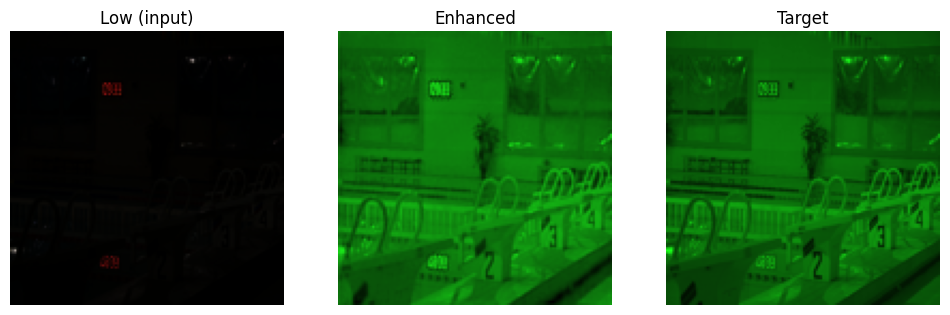

In [34]:
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    low, high = next(iter(test_loader))
    pred = model(low.to(device))

# Convert output to night vision
night = to_night_vision(pred[0].unsqueeze(0))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(low[0].permute(1,2,0).numpy());  axes[0].set_title("Low (input)")
axes[1].imshow(night);                           axes[1].set_title("Enhanced")
axes[2].imshow(high[0].permute(1,2,0).numpy()); axes[2].set_title("Target")
for ax in axes: ax.axis('off')
plt.show()

In [15]:
"~/Desktop/VS code projects/IMG_1816"

'~/Desktop/VS code projects/IMG_1816'

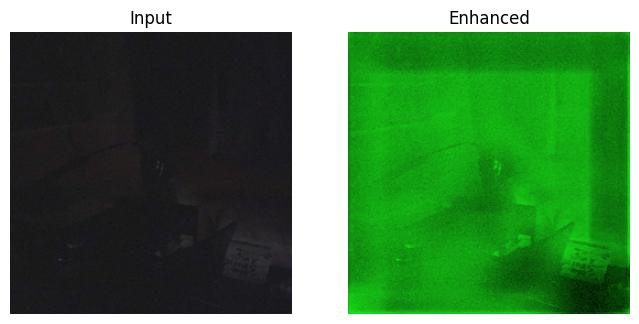

In [35]:
img = Image.open(os.path.expanduser("~/Desktop/VS code projects/IMG_1820.png")).convert("RGB")
img_resized = img.resize((256, 256))  # must match training size

tensor = torch.tensor(np.array(img_resized) / 255.0, dtype=torch.float32)
tensor = tensor.permute(2, 0, 1).unsqueeze(0).to(device)

model.eval()
with torch.inference_mode():
    pred = model(tensor)

# Convert to night vision
night = to_night_vision(pred[0].unsqueeze(0))

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(np.array(img_resized) / 255.0); axes[0].set_title("Input")
axes[1].imshow(night);                          axes[1].set_title("Enhanced")
for ax in axes: ax.axis('off')
plt.show()

In [36]:
torch.save(model.state_dict(), os.path.expanduser("~/Desktop/VS code projects/unet_model.pth"))
print("Model saved!")

Model saved!


In [23]:

def enhance_video(input_path, output_path, model, device, size=(256, 256), batch_size=1, smoothing=0.7):
    input_path  = os.path.expanduser(input_path)
    output_path = os.path.expanduser(output_path)

    cap = cv2.VideoCapture(input_path)
    fps    = cap.get(cv2.CAP_PROP_FPS)
    orig_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    orig_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"Video: {total} frames at {fps:.1f} FPS — original size {orig_w}x{orig_h}")

    frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, size, interpolation=cv2.INTER_LANCZOS4)
        frames.append(frame / 255.0)
    cap.release()

    frames_tensor = torch.tensor(np.array(frames), dtype=torch.float32).permute(0, 3, 1, 2)
    enhanced = []
    model.eval()
    with torch.inference_mode():
        for i in range(0, len(frames_tensor), batch_size):
            batch = frames_tensor[i:i+batch_size].to(device)
            out   = model(batch).cpu()
            enhanced.append(out)
            print(f"Processed {min(i+batch_size, len(frames_tensor))}/{len(frames_tensor)} frames", end="\r")
    enhanced = torch.cat(enhanced, dim=0)

    # Temporal smoothing
    out_frames = enhanced.permute(0, 2, 3, 1).numpy()
    smoothed = [out_frames[0]]
    for i in range(1, len(out_frames)):
        blended = smoothing * smoothed[-1] + (1 - smoothing) * out_frames[i]
        smoothed.append(blended)
    out_frames = (np.array(smoothed) * 255).clip(0, 255).astype(np.uint8)

    # Sharpen kernel
    sharpen_kernel = np.array([[ 0, -1,  0],
                                [-1,  5, -1],
                                [ 0, -1,  0]], dtype=np.float32)

    writer = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (orig_w, orig_h))
    for frame in out_frames:
        frame_bgr = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
        # Better quality upscaling
        frame_bgr = cv2.resize(frame_bgr, (orig_w, orig_h), interpolation=cv2.INTER_LANCZOS4)
        # Sharpen
        frame_bgr = cv2.filter2D(frame_bgr, -1, sharpen_kernel)
        writer.write(frame_bgr)

    writer.release()
    print(f"\nSaved to {output_path}")

enhance_video(
    input_path  = "~/Desktop/image intensifier examples/IMG_1824.mov",
    output_path = "~/Desktop/image intensifier examples/enhanced_video.mp4",
    model       = model,
    device      = device,
    smoothing   = 0.85
)

Video: 419 frames at 60.0 FPS — original size 1080x1920
Processed 419/419 frames
Saved to /Users/susiewonfor/Desktop/image intensifier examples/enhanced_video.mp4


In [19]:
cv2.destroyAllWindows()